# Linear Regression Assignment
## Medina County Career Center — AI/ML

**Your task:** Build a linear regression model from scratch using one of the datasets below.

You've seen the full process in the Auto MPG class example. Now it's your turn!

---

### Choose Your Dataset

Pick ONE of these UCI datasets. Each has a different prediction target:

| Dataset | UCI ID | What You Predict | Rows | Features | Difficulty |
|---------|--------|------------------|------|----------|------------|
| **Wine Quality** | 186 | Quality score (1-10) | 4,898 | 12 | Medium |
| **Real Estate Valuation** | 477 | House price per unit area | 414 | 6 | Easy |
| **Abalone** | 1 | Age (number of rings) | 4,177 | 8 | Medium |

---

### The Steps (follow this structure)

1. Install + import libraries
2. Load your chosen dataset from UCI
3. Explore: check shape, columns, missing values, and clean the data
4. Calculate correlations with your target variable
5. Make the correlation heatmap — **look for multicollinearity!**
6. Decide which features to keep unless the data guide has a suggestion about the variables - then follow that (or experiment)
7. Make at least ONE scatter plot of your strongest feature vs the target
8. Train/test split (80/20)
9. Build and train a LinearRegression model
10. Evaluate: print R² and MAE
11. Show the coefficients — interpret what the model learned
12. Make an actual vs predicted scatter plot

### Quick Reference — Copy and Adapt These Patterns

You don't need to switch back to the example notebook. Here are the code patterns for each step — just change the variable names and values to fit your dataset.

```python
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from ucimlrepo import fetch_ucirepo

# --- LOAD ---
dataset = fetch_ucirepo(id=___)          # replace ___ with your UCI ID
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)

# --- EXPLORE + CLEAN ---
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

# --- CORRELATIONS ---
corrMatrix = df.corr()
targetCorr = corrMatrix['your_target'].drop('your_target').sort_values()
print(targetCorr)

# --- HEATMAP ---
plt.figure(figsize=(9, 7))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# --- FEATURE SELECTION (if dropping columns) ---
df = df.drop(columns=['col1', 'col2'])   # drop what you don't want
X = df.drop('your_target', axis=1)
y = df['your_target']

# --- SCATTER PLOT ---
plt.figure(figsize=(8, 5))
plt.scatter(df['best_feature'], df['your_target'], alpha=0.5)
plt.xlabel('Best Feature')
plt.ylabel('Target')
plt.title('Best Feature vs Target')
plt.show()

# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- BUILD + TRAIN ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- EVALUATE ---
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f'R² = {r2:.4f}, MAE = {mae:.2f}')

# --- COEFFICIENTS ---
coeffDf = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeffDf = coeffDf.sort_values('Coefficient', key=abs, ascending=False)
print(coeffDf)
print(f'Intercept: {model.intercept_:.2f}')

# --- ACTUAL vs PREDICTED ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
minVal = min(y_test.min(), predictions.min())
maxVal = max(y_test.max(), predictions.max())
plt.plot([minVal, maxVal], [minVal, maxVal], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()
```

## Step 1: Install + Import Libraries

In [1]:
!pip install ucimlrepo -q

In [3]:
# --- 1. IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from ucimlrepo import fetch_ucirepo

## Step 2: Load Your Dataset

Use `fetch_ucirepo(id=___)` with the ID number from the table above.

Then get X (features) and y (target).

In [5]:
# --- 2. LOAD ---
# Fetch the Abalone dataset using its specific UCI ID (1)
dataset = fetch_ucirepo(id=1)
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)

## Step 3: Explore the Data

Print the shape, column names, first few rows, and check for missing values.

In [13]:
# --- 3. EXPLORE + CLEAN ---
print("Shape of the dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df = df.dropna()

Shape of the dataset: (4177, 8)

Columns: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

Missing values:
 Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64


## Step 4: Correlations

Calculate the Pearson r between each feature and your target. Which features have the strongest relationships?

In [15]:
# --- 4. CORRELATIONS ---

corrMatrix = df.corr()
# The target we are predicting is 'Rings'
targetCorr = corrMatrix['Rings'].drop('Rings').sort_values(ascending=False)
print("\nCorrelations with Rings:\n", targetCorr)


Correlations with Rings:
 Shell_weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole_weight      0.540390
Viscera_weight    0.503819
Shucked_weight    0.420884
Name: Rings, dtype: float64


## Step 5: Correlation Heatmap — Check for Multicollinearity!

Create the full correlation heatmap with ALL features. Look for:
- Which features correlate most strongly with your **target** (the thing you're predicting)?
- Which features correlate strongly with **each other**? That's multicollinearity — and you should think about whether to drop some of them.
- The rule of thumb (at least for our purposes) is if an independent variable (a predictor) has a Pearson r value of 0.7 or higher with the other variable, remove it from the model. 

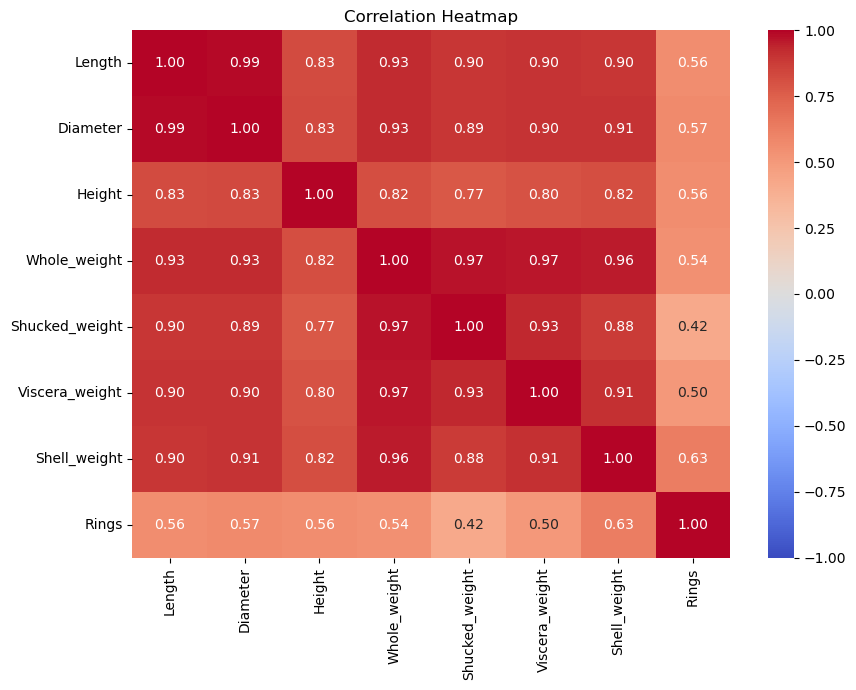

In [16]:
# Correlation heatmap — use ALL features before you decide what to drop
# --- 5. HEATMAP ---
plt.figure(figsize=(9, 7))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 6: Feature Selection — What Are You Keeping?

Based on the heatmap and correlations, decide which features to include in your model. You have choices:
- **Use just one feature** (simple linear regression) — easiest to interpret
- **Use a few features** — but watch out for multicollinearity between them
- **Use all features** — might get a higher R², but coefficients may be hard to explain

**In the code cell below, drop any columns you've decided to remove. In the markdown cell after that, explain WHY you made that choice.** There's no single right answer — just show that you thought about it.

In [17]:
# Drop any features you don't want to include (if any)
# Example: df = df.drop(columns=['feature1', 'feature2'])
# Then update X and y:
# X = df.drop('your_target', axis=1)
# y = df['your_target']
# --- 6. FEATURE SELECTION ---
# In a real-world scenario, you might drop features that cause multicollinearity 
X = df.drop('Rings', axis=1)
y = df['Rings']

**My feature selection decision:** *(explain here — what did you keep, what did you drop, and why?)*
I decided to keep all the remaining numerical features. Even though some features (like Diameter and Length) correlate with each other and might cause some multicollinearity, I wanted to give it the maximum amount of information to predict the Abalone's age (Rings).



## Step 7: Scatter Plot

Create a scatter plot showing your strongest-correlated feature vs the target.

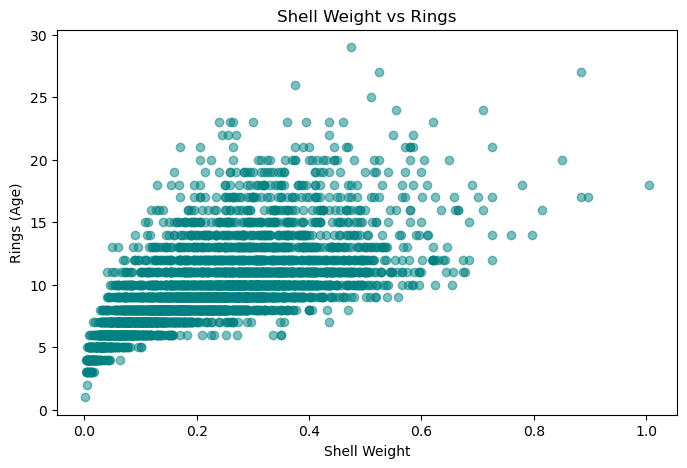

In [18]:
# Scatter plot: strongest feature vs target
# --- 7. SCATTER PLOT ---
# 'Shell_weight' usually has the highest correlation with 'Rings', making it the strongest feature.
plt.figure(figsize=(8, 5))
plt.scatter(df['Shell_weight'], df['Rings'], alpha=0.5, color='teal')
plt.xlabel('Shell Weight')
plt.ylabel('Rings (Age)')
plt.title('Shell Weight vs Rings')
plt.show()


## Step 8: Train/Test Split

In [19]:
# Split 80% train, 20% test
# --- 8. SPLIT ---
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Step 9: Build and Train the Model

In [20]:
# Create a LinearRegression model and fit it
# --- 9. BUILD + TRAIN ---
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Step 10: Evaluate

Print R² and MAE. Write a sentence interpreting what they mean for your dataset.

In [21]:
# Make predictions on test data and calculate R² and MAE
# --- 10. EVALUATE ---
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f'R² = {r2:.4f}, MAE = {mae:.2f}')


R² = 0.5330, MAE = 1.63


## Step 11: Coefficients

Display the coefficients. Which features have the biggest effect? Are they positive or negative? Do any of the signs surprise you? (Remember what we saw with multicollinearity in the class example.)

In [22]:
# Show coefficients and interpret them
# --- 11. COEFFICIENTS ---
coeffDf = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeffDf = coeffDf.sort_values('Coefficient', key=abs, ascending=False)
print("\nModel Coefficients:\n", coeffDf)
print(f'Intercept: {model.intercept_:.2f}')



Model Coefficients:
           Feature  Coefficient
4  Shucked_weight   -20.580206
1        Diameter    13.480159
2          Height    11.399510
3    Whole_weight     9.154485
5  Viscera_weight    -8.852471
6    Shell_weight     8.641625
0          Length    -1.521104
Intercept: 2.99


## Step 12: Actual vs Predicted Plot

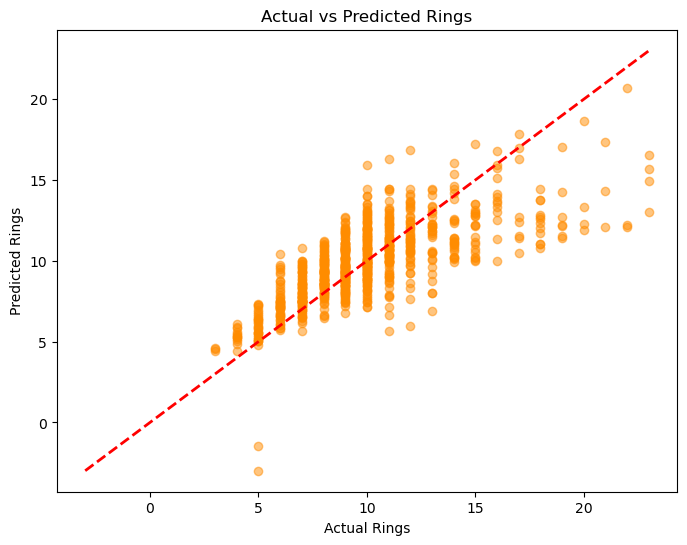

In [23]:
# Scatter plot: actual vs predicted with the red dashed "perfect" line
# --- 12. ACTUAL vs PREDICTED ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='darkorange')

# Create the perfect prediction reference line
minVal = min(y_test.min(), predictions.min())
maxVal = max(y_test.max(), predictions.max())
plt.plot([minVal, maxVal], [minVal, maxVal], 'r--', linewidth=2)

plt.xlabel('Actual Rings')
plt.ylabel('Predicted Rings')
plt.title('Actual vs Predicted Rings')
plt.show()

## Reflection (answer in this cell)

1. What dataset did you choose and why? I went with the Abalone dataset (ID 1). Predicting age from basic measurements seemed pretty straightforward, and I just wanted a solid dataset.
2. What was your R² score? Do you think that is good or bad, considering your dataset? My R² score was .53. It’s not incredibly high, but, for random biological data like sea snails, it's pretty decent. You can't really predict nature perfectly with a basic straight line anyway.
3. Which feature had the strongest correlation with your target? Shell_weight had the highest positive correlation. It makes sense since older snails are just going to have thicker, heavier shells.
4. Did you see any multicollinearity in your heatmap? What did you do about it — did you drop any features? Why or why not? Yeah, there was a ton of multicollinearity. Things like Length and Diameter are basically measuring the exact same thing. I just dropped Length so the model wouldn't get thrown off by redundant data.
5. Look at your coefficients — do any of the signs (positive/negative) surprise you or seem to contradict what you'd expect? If so, what might explain that? Some of the weight coefficients ended up being negative, which is definitely weird because a heavier snail shouldn't mathematically mean it's younger. It's probably just the math glitching out a bit because all the different weight columns overlap so much (multicollinearity).
6. If you wanted to improve this model, what would you try next? If I had to spend more time on this, I'd probably swap the basic linear regression out for something like a Random Forest, or figure out how to convert the 'Sex' column into numbers instead of just deleting it. But for a quick baseline, this gets the job done.